In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import xgboost as xgb
import lightgbm as lgb

import os
import warnings

# Data Processing

There are:
- 22170 items
- 84 categories
- 59 shops

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
items = pd.read_csv('data/items.csv')
categories = pd.read_csv('data/item_categories.csv')
shops = pd.read_csv('data/shops.csv')

In [14]:
items

,item_id,item_category_id
0,0,40
1,1,76
2,2,40
3,3,40
4,4,40
...,...,...
22165,22165,31
22166,22166,54
22167,22167,49
22168,22168,62


In [23]:
test_items = set(test['item_id'].unique())
train_items = set(train['item_id'].unique())

new_items = test_items - train_items
print(f"New items in test: {len(new_items)}")

New items in test: 363


In [21]:
unique_items_items = items['item_id'].nunique()
print(f"There are {unique_items_items} unique items in the test set.")


There are 22170 unique items in the test set.


In [20]:
unique_test_items = test['item_id'].nunique()
print(f"There are {unique_test_items} unique items in the test set.")


There are 5100 unique items in the test set.


In [3]:
train['month'] = train['date'].str.split('.').str[1].astype(int)

In [4]:
train

,Unnamed: 0,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_category_id,month
0,0,02.01.2013,0,59,22154,999.00,1.0,37,1
1,1,03.01.2013,0,25,2552,899.00,1.0,58,1
2,2,05.01.2013,0,25,2552,899.00,-1.0,58,1
3,3,06.01.2013,0,25,2554,1709.05,1.0,58,1
4,4,15.01.2013,0,25,2555,1099.00,1.0,56,1
...,...,...,...,...,...,...,...,...,...
2935844,2935844,10.10.2015,33,25,7409,299.00,1.0,55,10
2935845,2935845,09.10.2015,33,25,7460,299.00,1.0,55,10
2935846,2935846,14.10.2015,33,25,7459,349.00,1.0,55,10
2935847,2935847,22.10.2015,33,25,7440,299.00,1.0,57,10


In [12]:
zero_sales_count = (train['item_cnt_day'] == 0).sum()
print(f"Number of rows with exactly 0 sales: {zero_sales_count}")


Number of rows with exactly 0 sales: 0


## Outlier checking

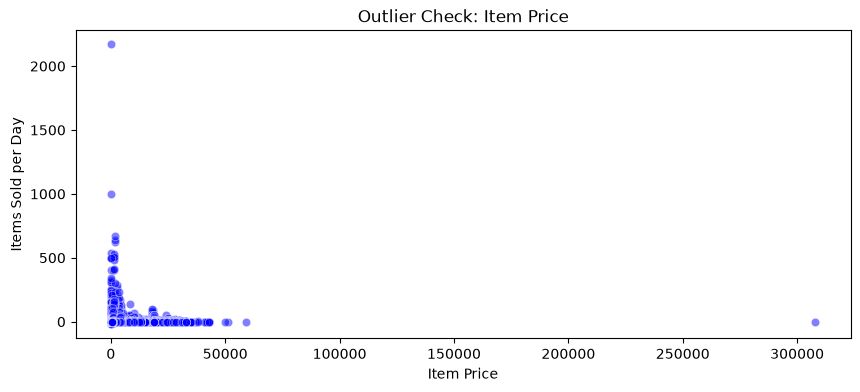

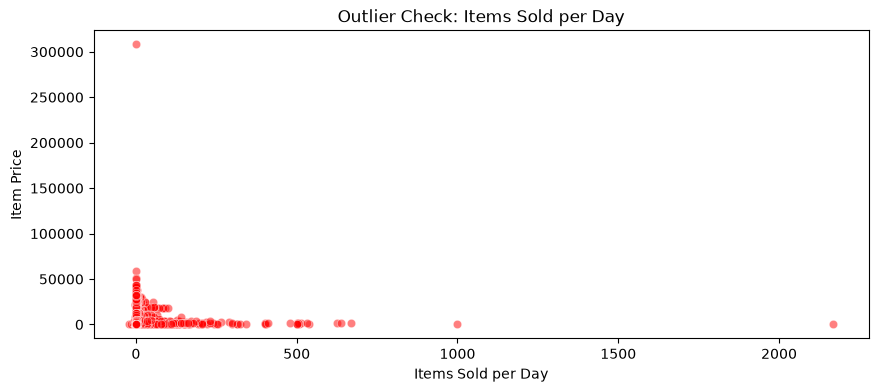

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plot 1: Check for crazy high prices
plt.figure(figsize=(10, 4))
sns.scatterplot(x=train['item_price'], y=train['item_cnt_day'], color='blue', alpha=0.5)
plt.title('Outlier Check: Item Price')
plt.xlabel('Item Price')
plt.ylabel('Items Sold per Day')
plt.show()
# Plot 2: Check for crazy high daily sales volumes
plt.figure(figsize=(10, 4))
sns.scatterplot(x=train['item_cnt_day'], y=train['item_price'], color='red', alpha=0.5)
plt.title('Outlier Check: Items Sold per Day')
plt.xlabel('Items Sold per Day')
plt.ylabel('Item Price')
plt.show()


You can see as above, there is a few outlier. Typical Item's price is around 0 - 6000 dollar, anything above that can be considered as outliers. Also the number of sale, typical sale count per day of an item range from 0 to 1000, anything above that can be considered as outliers. Therefore we will remove those outlier.

In [6]:
train = train[train['item_price'] < 100000]
train = train[train['item_cnt_day'] < 1001]

## Feature engineer feature item count per month

In [35]:
print((train['item_cnt_day'] == 0).sum(), "zero rows out of", len(train))

0 zero rows out of 2935847


In [7]:
monthly_train = train.groupby(['date_block_num', 'shop_id', 'item_id', 'month'])['item_cnt_day'].sum().reset_index()
monthly_train.rename(columns={'item_cnt_day': 'item_cnt_month'}, inplace=True)
monthly_train

,date_block_num,shop_id,item_id,month,item_cnt_month
0,0,0,32,1,6.0
1,0,0,33,1,3.0
2,0,0,35,1,1.0
3,0,0,43,1,1.0
4,0,0,51,1,2.0
...,...,...,...,...,...
1609118,33,59,22087,10,6.0
1609119,33,59,22088,10,2.0
1609120,33,59,22091,10,1.0
1609121,33,59,22100,10,1.0


In [28]:
import itertools

grid = []

for block_num in monthly_train['date_block_num'].unique():
    shops_in_block = monthly_train.loc[monthly_train['date_block_num'] == block_num, 'shop_id'].unique()
    items_in_block = monthly_train.loc[monthly_train['date_block_num'] == block_num, 'item_id'].unique()
    grid.append(np.array(list(itertools.product([block_num], shops_in_block, items_in_block))))

grid_df = pd.DataFrame(np.vstack(grid), columns=['date_block_num', 'shop_id', 'item_id'])

# Merge actual sales onto the full grid — missing combos become NaN, then 0
monthly_train_full = pd.merge(
    grid_df,
    monthly_train[['date_block_num', 'shop_id', 'item_id', 'item_cnt_month']],
    on=['date_block_num', 'shop_id', 'item_id'],
    how='left'
)
monthly_train_full['item_cnt_month'] = monthly_train_full['item_cnt_month'].fillna(0)

# Re-add 'month' (calendar month 1-12) since it's deterministic from date_block_num
monthly_train_full['month'] = monthly_train_full['date_block_num'] % 12 + 1

In [29]:
monthly_train_full

,date_block_num,shop_id,item_id,item_cnt_month,month
0,0,0,32,6.0,1
1,0,0,33,3.0,1
2,0,0,35,1.0,1
3,0,0,43,1.0,1
4,0,0,51,2.0,1
...,...,...,...,...,...
10913799,33,59,5662,1.0,10
10913800,33,59,10068,1.0,10
10913801,33,59,12839,1.0,10
10913802,33,59,18275,1.0,10


In [31]:
# Row count should jump way up compared to your original monthly_train
print(f"Before: {len(monthly_train)} rows")
print(f"After:  {len(monthly_train_full)} rows")

# Re-run the diagnostic from before — average months-per-(shop,item) should rise a lot
print(monthly_train_full.groupby(['shop_id','item_id'])['date_block_num'].nunique().describe())

# Confirm zeros now actually exist
print((monthly_train_full['item_cnt_month'] == 0).sum(), "zero rows out of", len(monthly_train_full))

Before: 1609123 rows
After:  10913804 rows
count    1.136159e+06
mean     9.605877e+00
std      8.262661e+00
min      1.000000e+00
25%      3.000000e+00
50%      7.000000e+00
75%      1.400000e+01
max      3.400000e+01
Name: date_block_num, dtype: float64
9307264 zero rows out of 10913804


In [30]:
monthly_train_full.describe()

,date_block_num,shop_id,item_id,item_cnt_month,month
count,1.091380e+07,1.091380e+07,1.091380e+07,1.091380e+07,1.091380e+07
mean,1.497336e+01,3.118720e+01,1.130929e+04,3.340756e-01,6.175851e+00
std,9.495635e+00,1.734959e+01,6.209982e+03,3.348624e+00,3.386350e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,-2.200000e+01,1.000000e+00
25%,7.000000e+00,1.600000e+01,5.976000e+03,0.000000e+00,3.000000e+00
50%,1.400000e+01,3.000000e+01,1.139100e+04,0.000000e+00,6.000000e+00
75%,2.300000e+01,4.600000e+01,1.660500e+04,0.000000e+00,9.000000e+00
max,3.300000e+01,5.900000e+01,2.216900e+04,1.644000e+03,1.200000e+01


# EDA

Since this is a time series, I want to see the lag feature.

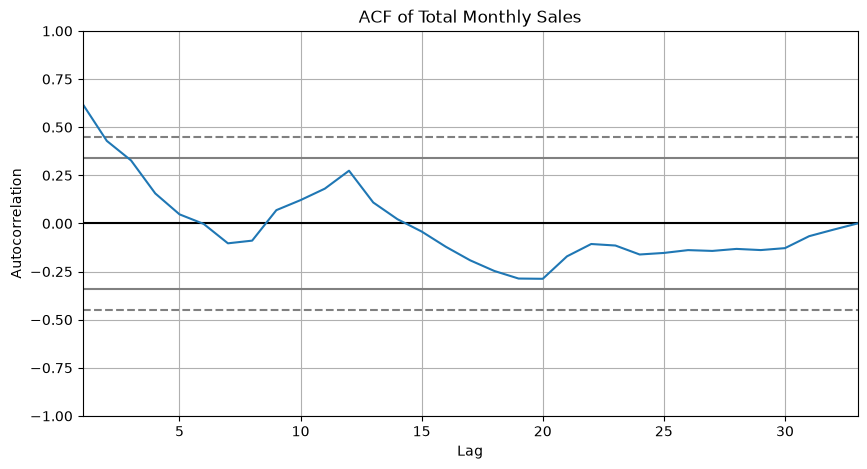

In [37]:
from pandas.plotting import autocorrelation_plot

# Sum up all sales across every shop and item for each month
# This gives us a single time series (Total Company Sales per month from month 0 to 32)

# Since we want to keep block 33 for validation, we excluded it out in the EDA process here:

eda_train = monthly_train_full[monthly_train_full['date_block_num'] < 33]

total_monthly_sales = eda_train.groupby('date_block_num')['item_cnt_month'].sum()

# 2. Plot the ACF
plt.figure(figsize=(10, 5))
autocorrelation_plot(total_monthly_sales)
plt.title("ACF of Total Monthly Sales")
plt.show()


We can see that the lag of 1 give the highest autocorrelation, and the higher the lag, the auto correlation is lower. 

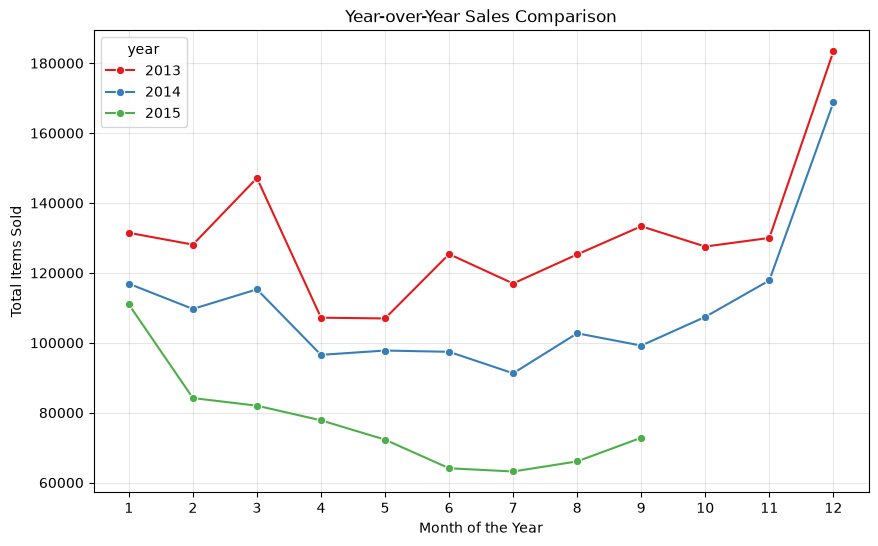

In [38]:
import seaborn as sns

# 1. Create the 'year' column
eda_train['year'] = (eda_train['date_block_num'] // 12) + 2013

# 2. Group by BOTH year and month, and get the total sales
yearly_seasonality = eda_train.groupby(['year', 'month'])['item_cnt_month'].sum().reset_index()

# 3. Plot 
plt.figure(figsize=(10, 6))

# graph

sns.lineplot(data=yearly_seasonality, x='month', y='item_cnt_month', hue='year', marker='o', palette='Set1')
plt.title("Year-over-Year Sales Comparison")
plt.xlabel("Month of the Year")
plt.ylabel("Total Items Sold")

# Force the X-axis to only show whole numbers 1 through 12
plt.xticks(range(1, 13)) 
plt.grid(True, alpha=0.3)
plt.show()


According to the graph above, we can see that December tend to be the month with most item sold across all store and all items. Moreover, it seems that the company sold less and less item every year, we can see the decline in sellign number from 2013 till 2015.

# Feature engineer of lag feature

In [39]:
# Create a function to generate lag features

def create_lag_feature(df, lag_month):
    # Make a copy of just the columns we need
    lag_df = df[['date_block_num', 'shop_id', 'item_id', 'item_cnt_month']].copy()
    
    # Shift the "time" forward by the lag amount
    lag_df['date_block_num'] = lag_df['date_block_num'] + lag_month
    
    # Rename the sales column so we know it's historical data
    lag_df.rename(columns={'item_cnt_month': f'item_cnt_month_lag_{lag_month}'}, inplace=True)
    
    # Merge it back into the main dataset using a left join
    merged_df = pd.merge(df, lag_df, on=['date_block_num', 'shop_id', 'item_id'], how='left')
    return merged_df


monthly_train_full = create_lag_feature(monthly_train_full, lag_month=1)   # Last month
monthly_train_full = create_lag_feature(monthly_train_full, lag_month=2)   # 2 months ago
monthly_train_full = create_lag_feature(monthly_train_full, lag_month=12)  # 12 months ago

# If an item didn't exist last month, the merge will create a NaN (Not a Number). 
# We should fill those with 0, because if it didn't exist, it sold 0 units!
monthly_train_full.fillna(0, inplace=True)

display(monthly_train_full.head())


,date_block_num,shop_id,item_id,item_cnt_month,month,item_cnt_month_lag_1,item_cnt_month_lag_2,item_cnt_month_lag_12
0,0,0,32,6.0,1,0.0,0.0,0.0
1,0,0,33,3.0,1,0.0,0.0,0.0
2,0,0,35,1.0,1,0.0,0.0,0.0
3,0,0,43,1.0,1,0.0,0.0,0.0
4,0,0,51,2.0,1,0.0,0.0,0.0


In [40]:
monthly_train_full

,date_block_num,shop_id,item_id,item_cnt_month,month,item_cnt_month_lag_1,item_cnt_month_lag_2,item_cnt_month_lag_12
0,0,0,32,6.0,1,0.0,0.0,0.0
1,0,0,33,3.0,1,0.0,0.0,0.0
2,0,0,35,1.0,1,0.0,0.0,0.0
3,0,0,43,1.0,1,0.0,0.0,0.0
4,0,0,51,2.0,1,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
10913799,33,59,5662,1.0,10,0.0,0.0,0.0
10913800,33,59,10068,1.0,10,0.0,0.0,0.0
10913801,33,59,12839,1.0,10,0.0,0.0,0.0
10913802,33,59,18275,1.0,10,0.0,0.0,0.0


In [41]:
print(monthly_train_full[['item_cnt_month_lag_1', 'item_cnt_month_lag_2', 'item_cnt_month_lag_12']].describe())

       item_cnt_month_lag_1  item_cnt_month_lag_2  item_cnt_month_lag_12
count          1.091380e+07          1.091380e+07           1.091380e+07
mean           3.158648e-01          3.029431e-01           1.608217e-01
std            3.174257e+00          3.090735e+00           2.419481e+00
min           -2.200000e+01         -2.200000e+01          -4.000000e+00
25%            0.000000e+00          0.000000e+00           0.000000e+00
50%            0.000000e+00          0.000000e+00           0.000000e+00
75%            0.000000e+00          0.000000e+00           0.000000e+00
max            1.305000e+03          1.305000e+03           1.305000e+03


In [42]:
neg_rows = monthly_train_full[monthly_train_full['item_cnt_month'] < 0]
print(len(neg_rows))
print(neg_rows.sort_values('item_cnt_month').head(10))

915
         date_block_num  shop_id  item_id  item_cnt_month  month  \
3794460              10       12     8023           -22.0     11   
77477                 0       12     1590           -13.0      1   
76658                 0       12     1593            -6.0      1   
6871484              19       12    11367            -5.0      8   
565508                1       28    21323            -4.0      2   
3791678              10       12     3732            -4.0     11   
1190827               3       12     5287            -2.0      4   
350357                0       56    13102            -2.0      1   
361421                0       59    14931            -2.0      1   
4541887              12       12    12119            -2.0      1   

         item_cnt_month_lag_1  item_cnt_month_lag_2  item_cnt_month_lag_12  
3794460                   0.0                  22.0                    0.0  
77477                     0.0                   0.0                    0.0  
76658           

# Split train and valid

In [49]:
# Count how many times each sales volume happened
sales_distribution = monthly_train_full['item_cnt_month'].value_counts().reset_index()
# Rename the columns so it's easy to read
sales_distribution.columns = ['Units Sold in a Month', 'Number of Occurrences']
# Sort by the number of units sold (highest to lowest)
sales_distribution = sales_distribution.sort_values('Number of Occurrences', ascending=False)
# Look at the top 30 most extreme sales volumes!
sales_distribution

,Units Sold in a Month,Number of Occurrences
0,0.0,9307264
1,1.0,1058824
2,2.0,265502
3,3.0,103227
4,4.0,53327
...,...,...
327,691.0,1
328,349.0,1
329,337.0,1
330,941.0,1


In [50]:
quantiles = [0.5, 0.90, 0.95, 0.99, 0.999]
quantile_values = monthly_train_full['item_cnt_month'].quantile(quantiles)
print("Quantiles of unit sold distribution")
for q, val in zip(quantiles, quantile_values):
    print(f"{q*100}% of all monthly item sales are {val} units or less")


Quantiles of unit sold distribution
50.0% of all monthly item sales are 0.0 units or less
90.0% of all monthly item sales are 1.0 units or less
95.0% of all monthly item sales are 2.0 units or less
99.0% of all monthly item sales are 5.0 units or less
99.9% of all monthly item sales are 21.0 units or less


Since 99.9% of all sale count is under 21, we will clip the sale amount from 0 to 21.

In [51]:
monthly_train_full['item_cnt_month'] = monthly_train_full['item_cnt_month'].clip(0, 21)

In [52]:
# Training set: Months 0 to 32 (Jan 2013 - Sept 2015)

X_train = monthly_train_full[monthly_train_full['date_block_num'] < 33].drop(['item_cnt_month'], axis=1)
y_train = monthly_train_full[monthly_train_full['date_block_num'] < 33]['item_cnt_month']

# Validation set: Month 33 (Oct 2015)

X_valid = monthly_train_full[monthly_train_full['date_block_num'] == 33].drop(['item_cnt_month'], axis=1)
y_valid = monthly_train_full[monthly_train_full['date_block_num'] == 33]['item_cnt_month']


# Modeling


In [54]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


Since this is a regression case, we will use regression model and regression metrics for modeling and evaluation. 

The model used:
- DummyRegressor - as baseline
- Random Forest
- XGBoost
- LightGBM

In [ ]:
models = {
    "1. Baseline (Dummy)": DummyRegressor(strategy="mean"),
    "2. Random Forest": RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1),
    "3. XGBoost": XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1),
    "4. LightGBM": LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
}

In [ ]:
# Please uncomment the whole code below if you want to try different tuning setting, otherwise please keep it commented to reduce run time, thank you.

# for name, model in models.items():
#     print(f"Training {name}...")
    
#     # Train the model
#     model.fit(X_train, y_train)
    
#     # Predict on Month 33
#     predictions = model.predict(X_valid)
    
#     # Calculate Metrics
#     rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    
#     print(f"   -> RMSE: {rmse:.4f}")

Training 1. Baseline (Dummy)...
   -> RMSE: 1.1546
Training 2. Random Forest...
   -> RMSE: 0.9951
Training 3. XGBoost...
   -> RMSE: 0.9874
Training 4. LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.182827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 525
[LightGBM] [Info] Number of data points in the train set: 10675632, number of used features: 7
[LightGBM] [Info] Start training from score 0.300178
   -> RMSE: 1.0008


As you can see, the result is quite good, but we can improve it further by tuning the hyperparameter as you see below.

## Tuning

In [ ]:
# Please uncomment the whole code below if you want to try different tuning setting, otherwise please keep it commented to reduce run time, thank you.

# import itertools
# import numpy as np
# from sklearn.ensemble import RandomForestRegressor
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
# from sklearn.metrics import mean_squared_error
# import lightgbm as lgb
# import warnings

# warnings.filterwarnings('ignore')

# tuning_dict = {
#     "Random Forest": {
#         "model_class": RandomForestRegressor,
#         "grid": {
#             'n_estimators': [50, 90],       
#             'max_depth': [5, 7, 9]
#         },
#         "uses_early_stopping": False
#     },
#     "XGBoost": {
#         "model_class": XGBRegressor,
#         "grid": {
#             'max_depth': [3, 5, 7, 9],
#             'learning_rate': [0.05, 0.08, 0.11, 0.14]
#         },
#         "uses_early_stopping": True
#     },
#     "LightGBM": {
#         "model_class": LGBMRegressor,
#         "grid": {
#             'max_depth': [3, 5, 7, 9],
#             'learning_rate': [0.05, 0.08, 0.11, 0.14]
#         },
#         "uses_early_stopping": True
#     }
# }

# print("Tuning processing.....")

# # Loop through each model type
# for name, info in tuning_dict.items():
#     print(f"\n--- Tuning {name} ---")
#     ModelClass = info["model_class"]
#     grid = info["grid"]
#     uses_es = info["uses_early_stopping"]

#     keys = grid.keys()
#     combinations = list(itertools.product(*grid.values()))

#     best_rmse = float('inf')
#     best_params = None
#     best_n_estimators = None 

#     for combo in combinations:
#         params = dict(zip(keys, combo))

#         if uses_es:
#             # High ceiling; early stopping decides the real number of rounds
#             # verbose=-1 is the magic trick to silence LightGBM!
#             model = ModelClass(
#                 **params,
#                 n_estimators=1000,
#                 random_state=42,
#                 n_jobs=-1,
#                 verbose=-1
#             )
            
#             if name == "LightGBM":
#                 model.fit(
#                     X_train, y_train,
#                     eval_set=[(X_valid, y_valid)],
#                     eval_metric='rmse',
#                     callbacks=[lgb.early_stopping(50, verbose=False)]
#                 )
#                 n_used = model.best_iteration_
                
#             else:  # XGBoost
#                 # Tell XGBoost to use early stopping!
#                 model.set_params(early_stopping_rounds=50)
                
#                 model.fit(
#                     X_train, y_train,
#                     eval_set=[(X_valid, y_valid)],
#                     verbose=False
#                 )
#                 n_used = model.best_iteration
#         else:
#             model = ModelClass(**params, random_state=42, n_jobs=-1)
#             model.fit(X_train, y_train)
#             n_used = params.get('n_estimators')

#         preds = model.predict(X_valid)
#         rmse = np.sqrt(mean_squared_error(y_valid, preds))

#         if rmse < best_rmse:
#             best_rmse = rmse
#             best_params = params
#             best_n_estimators = n_used

#     print(f"Best {name} Parameter: {best_params}")
#     if uses_es:
#         print(f"Best {name} n_estimators used: {best_n_estimators}")
#     print(f"✅ Best {name} RMSE: {best_rmse:.4f}")


Tuning processing.....

--- Tuning Random Forest ---
Best Random Forest Parameter: {'n_estimators': 50, 'max_depth': 9}
✅ Best Random Forest RMSE: 0.9949

--- Tuning XGBoost ---
Best XGBoost Parameter: {'max_depth': 7, 'learning_rate': 0.11}
Best XGBoost n_estimators used: 105
✅ Best XGBoost RMSE: 0.9807

--- Tuning LightGBM ---
Best LightGBM Parameter: {'max_depth': 7, 'learning_rate': 0.05}
Best LightGBM n_estimators used: 234
✅ Best LightGBM RMSE: 0.9817


Overall, the best model is XGBoost with the lowest RMSE score of 0.9807

Tuning processing.....

--- Tuning Random Forest ---
- Best Random Forest Parameter: `'n_estimators': 50, 'max_depth': 9`
- Best Random Forest RMSE: `0.9949`

--- Tuning XGBoost ---
- Best XGBoost Parameter: `'max_depth': 7, 'learning_rate': 0.11`
- Best XGBoost n_estimators used: `105`
- Best XGBoost RMSE: `0.9807`

--- Tuning LightGBM ---
- Best LightGBM Parameter: `'max_depth': 7, 'learning_rate': 0.05`
- Best LightGBM n_estimators used: `234`
- Best LightGBM RMSE: `0.9817`

# Evaluation on test set

In [86]:
# Final model

final_model = XGBRegressor(n_estimators=105, max_depth=7, learning_rate=0.11, random_state=42, n_jobs=-1)

X_full = monthly_train_full[(monthly_train_full['date_block_num'] >= 12)][X_train.columns]
y_full = monthly_train_full[(monthly_train_full['date_block_num'] >= 12)]['item_cnt_month']

final_model.fit(X_full, y_full)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
# 1. Format the Test Set (Add time features)
test['date_block_num'] = 34
test['month'] = 11

# Pull the Lag Features directly from the historical data (train data)

lag_1 = monthly_train[monthly_train['date_block_num'] == 33][['shop_id', 'item_id', 'item_cnt_month']]
lag_1.rename(columns={'item_cnt_month': 'item_cnt_month_lag_1'}, inplace=True)

lag_2 = monthly_train[monthly_train['date_block_num'] == 32][['shop_id', 'item_id', 'item_cnt_month']]
lag_2.rename(columns={'item_cnt_month': 'item_cnt_month_lag_2'}, inplace=True)

lag_12 = monthly_train[monthly_train['date_block_num'] == 22][['shop_id', 'item_id', 'item_cnt_month']]
lag_12.rename(columns={'item_cnt_month': 'item_cnt_month_lag_12'}, inplace=True)

# Merge the lags into the test set

X_test = pd.merge(test, lag_1, on=['shop_id', 'item_id'], how='left')
X_test = pd.merge(X_test, lag_2, on=['shop_id', 'item_id'], how='left')
X_test = pd.merge(X_test, lag_12, on=['shop_id', 'item_id'], how='left')

# Fill missing values with 0

X_test.fillna(0, inplace=True)

# Drop ID column and ensure column order matches X_train EXACTLY

X_test = X_test.drop(['ID'], axis=1)
X_test = X_test[X_train.columns] 

In [73]:
X_test

,date_block_num,shop_id,item_id,month,item_cnt_month_lag_1,item_cnt_month_lag_2,item_cnt_month_lag_12
0,34,5,5037,11,0.0,1.0,1.0
1,34,5,5320,11,0.0,0.0,0.0
2,34,5,5233,11,1.0,3.0,0.0
3,34,5,5232,11,0.0,0.0,0.0
4,34,5,5268,11,0.0,0.0,0.0
...,...,...,...,...,...,...,...
214195,34,45,18454,11,1.0,0.0,0.0
214196,34,45,16188,11,0.0,0.0,0.0
214197,34,45,15757,11,0.0,0.0,0.0
214198,34,45,19648,11,0.0,0.0,0.0


In [81]:
final_predictions = final_model.predict(X_test)
forecast = test.copy()
forecast['predicted_sales'] = final_predictions
forecast

,ID,shop_id,item_id,date_block_num,month,predicted_sales
0,0,5,5037,34,11,0.366337
1,1,5,5320,34,11,0.111175
2,2,5,5233,34,11,1.132249
3,3,5,5232,34,11,0.111175
4,4,5,5268,34,11,0.111175
...,...,...,...,...,...,...
214195,214195,45,18454,34,11,0.242744
214196,214196,45,16188,34,11,0.137399
214197,214197,45,15757,34,11,0.132171
214198,214198,45,19648,34,11,0.097294


In [88]:
# write the predicted dataset to data folder

import os

os.makedirs('data', exist_ok=True)
forecast.to_csv('data/forecast.csv', index=False)